# **Data Preprocessing**

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.neighbors import NearestNeighbors

# Imputation
from sklearn.impute import KNNImputer

# Feature Selection and Scaling
from sklearn.preprocessing import RobustScaler

# Dimensionality Reduction
from sklearn.cluster import DBSCAN

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv('data/customer_info.csv')
dataset.head()

,Unnamed: 0,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,NaN,38.721807,-9.125534
1,1,6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,971840.0,38.734668,-9.163533
2,2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,NaN,38.787126,-9.147077
3,3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,NaN,38.741816,-9.159700
4,4,16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,925367.0,38.785921,-9.149221


Here, we set **customer_id as the index** because we found it more useful throughout the project, and we **dropped the Unnamed: 0** column since it was irrelevant.

In [3]:
dataset.set_index('customer_id', inplace=True)
dataset.drop('Unnamed: 0', axis=1, inplace=True)
dataset.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,5601.0,13.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,NaN,38.721807,-9.125534
6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,35.0,14.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,971840.0,38.734668,-9.163533
39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,4275.0,14.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,NaN,38.787126,-9.147077
21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,16366.0,14.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,NaN,38.741816,-9.159700
16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,3197.0,14.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,925367.0,38.785921,-9.149221


- Dropping **customer_name** column because the actual names of the customers were not relevant to our analysis; instead, we focused on their characteristics and IDs.
- Dropping **latitude** and **longitude** because we already used these variables for the map and will not be useful for clustering. But we will store them in a variable called coordinates so that we can use them in the end of the models section.

In [ ]:
dataset.drop('customer_name', axis=1, inplace=True)

coordinates = dataset[['latitude', 'longitude']].copy()

dataset.drop('latitude', axis=1, inplace=True)
dataset.drop('longitude', axis=1, inplace=True)

----------

## **FEATURE TRANSFORMATION**

### **customer_gender**

Transform customer_gender to switch 'female' customers to 0 and 'male' customers to 1

In [7]:
dataset['customer_gender'] = dataset['customer_gender'].map({'female': 0, 'male':1})

### **customer_age**

Converted customer_birthdate into customer_age to provide a more practical and meaningful attribute for customers.

In [9]:
from datetime import datetime

# Converting to datetime
dataset['customer_birthdate'] = pd.to_datetime(dataset['customer_birthdate'])

# Calculating customer's age
today = pd.to_datetime("today")
dataset['customer_age'] = ((today - dataset['customer_birthdate']).dt.days // 365).astype(int, errors='ignore')

dataset.drop('customer_birthdate', axis=1, inplace=True)

### **years_since_first_transaction**

Calculated the years_since_first_transaction providing a more relevant metric for customer tenure.

In [ ]:
current_year = pd.to_datetime("today").year

dataset['years_since_first_transaction'] = current_year - dataset['year_first_transaction']
dataset.drop('year_first_transaction', axis=1, inplace=True) # removed this column because it was directly correlated with the new column

### **percentage_of_products_bought_promotion**

For this variable, as we discovered that there existed a **big percentage of negative values**, we decided to convert values in the following way:

- Values > 0: converted to 1

- Values < 0: converted to 0

In [ ]:
dataset['percentage_of_products_bought_promotion'] = dataset['percentage_of_products_bought_promotion'].map(lambda x: 1 if x > 0 else 0)

### **loyalty_card_number**

For this variable, as we discovered that there existed a **big number of missing values**, we decided to convert values in the following way:

- Null Values: converted to 1

- Non-null Values: converted to 0

In [13]:
dataset['loyalty_card_number'] = dataset['loyalty_card_number'].map(lambda x: 1 if pd.isnull(x) else 0)

------------

## **IMPUTATION**

In [ ]:
imputer = KNNImputer(n_neighbors=5, weights='distance')

dataset_imp = pd.DataFrame(imputer.fit_transform(dataset), columns=dataset.columns, index=dataset.index)

# Copying the imputed dataset to a new variable
dataset = dataset_imp.copy()

Since the use of KNN Imputer resulted in float values for variables such as 'kids_home', 'teens_home', 'number_complaints' and 'distinct_stores_visited', we decided to **round all the values to the nearest unit**:

In [15]:
dataset['kids_home'] = round(dataset['kids_home'], 0)
dataset['teens_home'] = round(dataset['teens_home'], 0)
dataset['number_complaints'] = round(dataset['number_complaints'], 0)
dataset['distinct_stores_visited'] = round(dataset['distinct_stores_visited'], 0)

------------

### **OUTLIERS**

### **Unidimensional**

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34060 entries, 29930 to 22050
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_gender                          34060 non-null  float64
 1   kids_home                                34060 non-null  float64
 2   teens_home                               34060 non-null  float64
 3   number_complaints                        34060 non-null  float64
 4   distinct_stores_visited                  34060 non-null  float64
 5   lifetime_spend_groceries                 34060 non-null  float64
 6   lifetime_spend_electronics               34060 non-null  float64
 7   typical_hour                             34060 non-null  float64
 8   lifetime_spend_vegetables                34060 non-null  float64
 9   lifetime_spend_nonalcohol_drinks         34060 non-null  float64
 10  lifetime_spend_alcohol_drinks            34060 

In [ ]:
# dividing the dataset into four parts for easier visualization
dataset1 = dataset.loc[:, ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'customer_age']]
dataset2 = dataset.loc[:, ['lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks']]
dataset3 = dataset.loc[:, ['lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood']]
dataset4 = dataset.loc[:, ['percentage_of_products_bought_promotion', 'years_since_first_transaction', 'lifetime_total_distinct_products']]

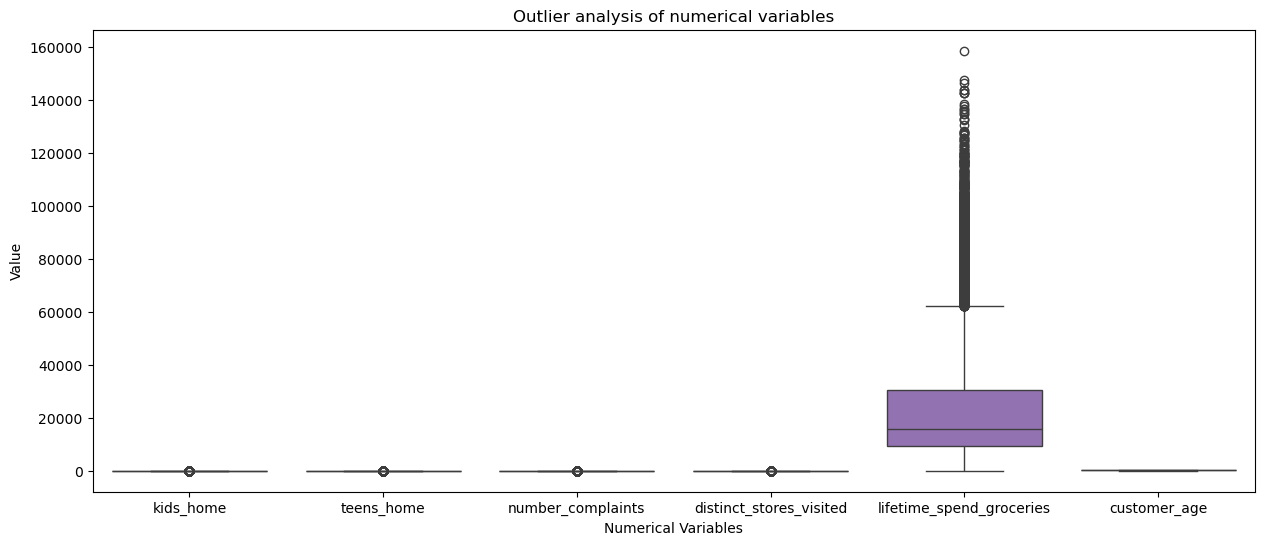

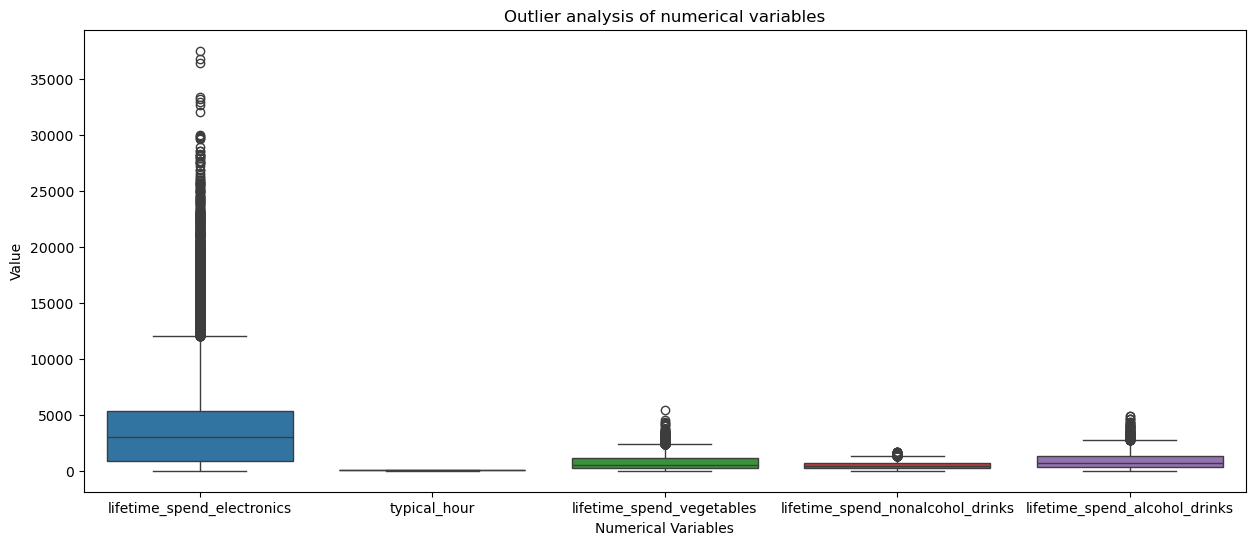

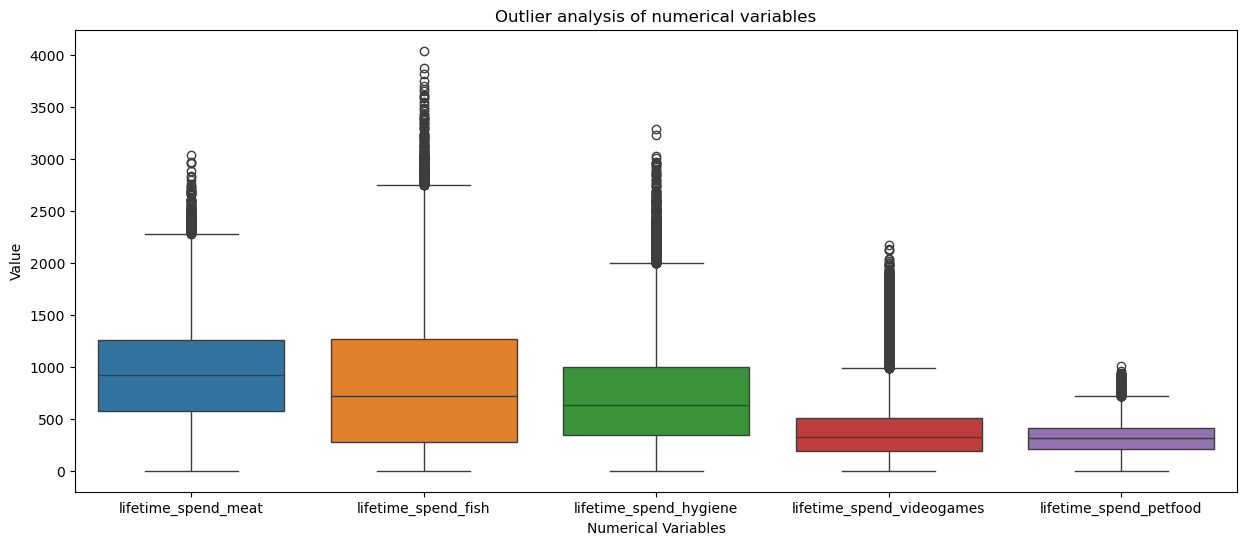

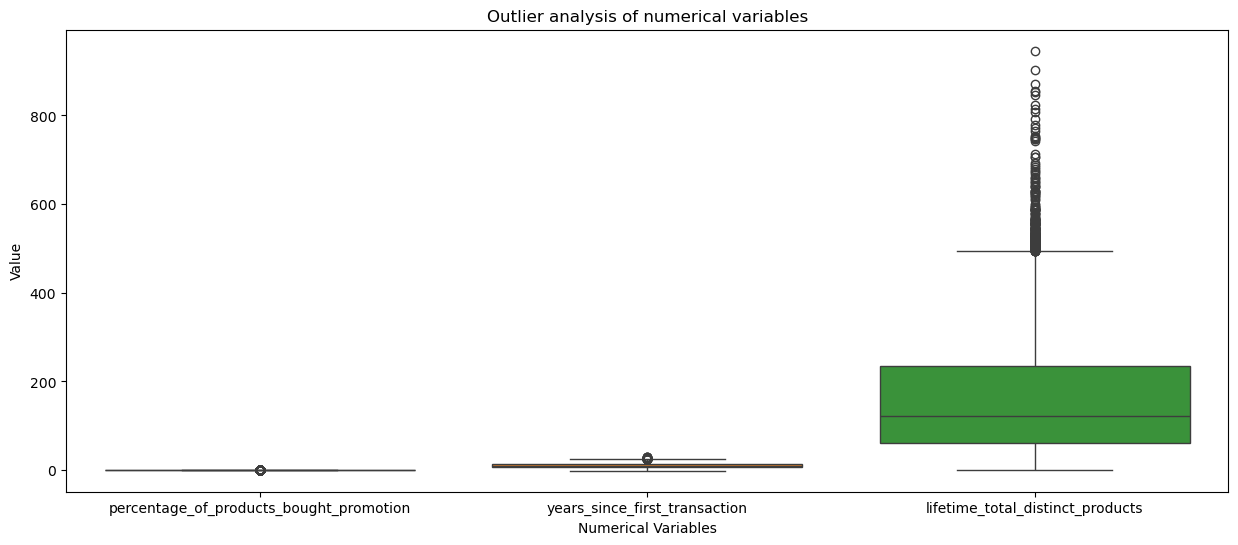

In [18]:
plt.figure(figsize=(15,6))
sns.boxplot(data=dataset1)
plt.xlabel('Numerical Variables')
plt.ylabel('Value')
plt.title('Outlier analysis of numerical variables')
plt.show()


plt.figure(figsize=(15,6))
sns.boxplot(data=dataset2)
plt.xlabel('Numerical Variables')
plt.ylabel('Value')
plt.title('Outlier analysis of numerical variables')
plt.show()


plt.figure(figsize=(15,6))
sns.boxplot(data=dataset3)
plt.xlabel('Numerical Variables')
plt.ylabel('Value')
plt.title('Outlier analysis of numerical variables')
plt.show()


plt.figure(figsize=(15,6))
sns.boxplot(data=dataset4)
plt.xlabel('Numerical Variables')
plt.ylabel('Value')
plt.title('Outlier analysis of numerical variables')
plt.show()

With that, we can clearly see that **lifetime_spend_groceries**, **lifetime_spend_electronics**, **lifetime_spend_vegetables**, **lifetime_spend_nonalcohol_drinks**, **lifetime_spend_alcohol_drinks**, **lifetime_spend_meat**, **lifetime_spend_fish**, **lifetime_spend_hygiene**, **lifetime_spend_videogames**, **lifetime_spend_petfood** and **lifetime_total_distinct_products** exhibit several outliers.

In [19]:
pd.set_option('display.max_columns', None) # to see all columns

At this moment, we will see deeper the variables that show more significant outliers:

### lifetime_spend_groceries

In [20]:
Q1_groceries = dataset['lifetime_spend_groceries'].quantile(0.25)
Q3_groceries = dataset['lifetime_spend_groceries'].quantile(0.75)
IQR_groceries = Q3_groceries - Q1_groceries
lower_bound_groceries = Q1_groceries - 1.5 * IQR_groceries
upper_bound_groceries = Q3_groceries + 1.5 * IQR_groceries

outliers = dataset[(dataset['lifetime_spend_groceries'] < lower_bound_groceries) | (dataset['lifetime_spend_groceries'] > upper_bound_groceries)]
display(outliers.sort_values('lifetime_spend_groceries', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_groceries', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
2116,0.0,0.0,1.0,0.0,2.0,158544.0,4156.0,19.000000,527.0,553.0,1382.0,847.0,1930.000000,890.0,638.0,639.0,89.0,1.0,0.0,83.000000,9.0
38873,1.0,0.0,1.0,0.0,2.0,147541.0,3192.0,14.000000,622.0,451.0,1139.0,1741.0,1962.000000,431.0,686.0,281.0,158.0,1.0,1.0,29.000000,6.0
24694,1.0,1.0,1.0,0.0,1.0,146161.0,5321.0,16.000000,593.0,519.0,1409.0,1785.0,2148.000000,910.0,742.0,190.0,233.0,1.0,0.0,74.000000,9.0
848,0.0,0.0,1.0,1.0,1.0,143753.0,6113.0,8.000000,634.0,438.0,1526.0,1395.0,2256.000000,523.0,538.0,324.0,138.0,1.0,0.0,63.854287,13.0
39708,0.0,0.0,1.0,0.0,3.0,143542.0,4059.0,16.000000,237.0,585.0,1527.0,1438.0,1632.000000,242.0,458.0,641.0,134.0,1.0,1.0,59.000000,16.0
22762,0.0,1.0,1.0,0.0,3.0,142551.0,1907.0,9.000000,1322.0,462.0,1093.0,1733.0,2163.000000,196.0,673.0,357.0,140.0,1.0,0.0,64.000000,16.0
34642,0.0,1.0,1.0,0.0,2.0,142399.0,8501.0,13.000000,1497.0,585.0,1495.0,1478.0,1887.000000,1456.0,756.0,420.0,61.0,1.0,1.0,68.000000,10.0
33741,1.0,1.0,0.0,1.0,1.0,142363.0,3284.0,18.000000,65.0,481.0,326.0,606.0,889.000000,1138.0,576.0,360.0,339.0,0.0,1.0,52.000000,19.0
33358,0.0,0.0,1.0,0.0,1.0,138568.0,7668.0,7.000000,1404.0,336.0,1171.0,945.0,1640.134733,507.0,625.0,409.0,86.0,1.0,1.0,64.000000,5.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
16673,0.0,0.0,2.0,1.0,4.0,62055.0,94.0,9.0,358.0,249.0,802.099712,1076.0,568.000000,1919.0,178.0,379.0,385.0,1.0,0.0,60.420404,14.0
18578,1.0,1.0,1.0,0.0,2.0,62057.0,8298.0,11.0,2345.0,698.0,1815.000000,1302.0,1438.000000,762.0,659.0,420.0,90.0,1.0,0.0,59.000000,17.0
3240,0.0,1.0,0.0,1.0,2.0,62059.0,74.0,14.0,724.0,528.0,226.000000,1087.0,1104.000000,451.0,772.0,563.0,136.0,1.0,0.0,61.000000,15.0
21186,1.0,0.0,1.0,0.0,3.0,62072.0,3948.0,15.0,1336.0,597.0,1622.000000,1381.0,1242.000000,1146.0,474.0,674.0,75.0,1.0,0.0,67.000000,16.0
32657,1.0,1.0,1.0,0.0,2.0,62079.0,5550.0,17.0,1570.0,417.0,1843.000000,1487.0,1302.000000,862.0,784.0,372.0,58.0,0.0,1.0,61.000000,13.0
35443,1.0,1.0,0.0,0.0,1.0,62093.0,6052.0,14.0,331.0,238.0,518.000000,976.0,971.000000,790.0,704.0,43.0,220.0,1.0,1.0,71.000000,12.0
39571,1.0,0.0,1.0,0.0,1.0,62142.0,4135.0,19.0,337.0,647.0,1611.000000,728.0,55.000000,852.0,578.0,406.0,153.0,1.0,1.0,57.000000,8.0
17542,1.0,2.0,1.0,1.0,4.0,62143.0,2624.0,9.0,263.0,689.0,646.000000,803.0,1513.000000,768.0,352.0,204.0,162.0,1.0,0.0,38.000000,6.0
1239,1.0,1.0,1.0,0.0,2.0,62186.0,4897.0,20.0,1340.0,600.0,1451.000000,1738.0,1351.000000,750.0,714.0,465.0,196.0,1.0,0.0,83.000000,19.0


As we have a huge number of outliers calculated by the formula, we will just **drop the very extreme values**.
Getting this into account, we will drop '2116' as it takes the value: **158544.0**

In [21]:
dataset.drop(2116, inplace=True)

---------------
### lifetime_spend_electronics

In [22]:
Q1_electronics = dataset['lifetime_spend_electronics'].quantile(0.25)
Q3_electronics = dataset['lifetime_spend_electronics'].quantile(0.75)
IQR_electronics = Q3_electronics - Q1_electronics
lower_bound_electronics = Q1_electronics - 1.5 * IQR_electronics
upper_bound_electronics = Q3_electronics + 1.5 * IQR_electronics

outliers = dataset[(dataset['lifetime_spend_electronics'] < lower_bound_electronics) | (dataset['lifetime_spend_electronics'] > upper_bound_electronics)]
display(outliers.sort_values('lifetime_spend_electronics', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_electronics', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
11695,1.0,1.0,0.0,1.0,1.0,4708.0,37523.0,14.000000,560.0,50.0,528.335072,893.0,1456.000000,1045.0,697.0,33.0,418.0,0.0,0.0,63.0,12.0
5696,0.0,0.0,0.0,1.0,1.0,17522.0,36794.0,20.000000,453.0,488.0,860.000000,488.0,889.000000,1136.0,939.0,287.0,186.0,1.0,0.0,52.0,12.0
34106,1.0,1.0,0.0,2.0,1.0,18383.0,36422.0,11.000000,372.0,305.0,651.000000,188.0,1769.000000,1062.0,655.0,166.0,92.0,1.0,1.0,63.0,11.0
2102,1.0,0.0,0.0,1.0,1.0,21223.0,33365.0,13.000000,69.0,1115.0,1450.000000,868.0,835.000000,876.0,503.0,78.0,325.0,1.0,0.0,58.0,5.0
19275,1.0,1.0,0.0,2.0,1.0,14544.0,33181.0,14.000000,277.0,24.0,677.000000,786.0,597.000000,1793.0,220.0,371.0,92.0,1.0,1.0,56.0,4.0
36247,1.0,0.0,0.0,2.0,1.0,25772.0,32930.0,11.000000,905.0,1193.0,729.000000,579.0,1892.000000,197.0,683.0,125.0,94.0,1.0,1.0,58.0,7.0
3885,0.0,0.0,0.0,0.0,3.0,27901.0,32661.0,6.000000,1053.0,266.0,423.000000,1076.0,590.000000,699.0,523.0,500.0,239.0,1.0,0.0,54.0,4.0
28827,0.0,0.0,0.0,1.0,1.0,58913.0,32029.0,9.000000,595.0,626.0,350.000000,182.0,1251.000000,712.0,553.0,175.0,16.0,1.0,1.0,75.0,8.0
17401,1.0,0.0,0.0,0.0,2.0,45532.0,29970.0,13.000000,57.0,649.0,798.000000,989.0,631.000000,691.0,736.0,628.0,510.0,1.0,1.0,72.0,5.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
30349,0.0,1.0,0.0,1.0,2.0,23640.0,11985.0,15.0,1010.0,514.0,221.0,1111.0,1456.000000,1440.0,623.0,428.0,278.0,1.0,1.0,28.0,5.0
3893,0.0,0.0,0.0,2.0,1.0,34485.0,11985.0,23.0,95.0,569.0,1304.0,735.0,705.000000,314.0,1029.0,352.0,218.0,1.0,0.0,81.0,4.0
27799,1.0,1.0,0.0,1.0,1.0,143.0,11987.0,15.0,996.0,289.0,324.0,983.0,1321.000000,1160.0,636.0,286.0,29.0,1.0,1.0,50.0,9.0
17580,0.0,0.0,0.0,1.0,2.0,9405.0,11997.0,24.0,23.0,686.0,1071.0,578.0,501.000000,224.0,1241.0,215.0,54.0,1.0,0.0,66.0,14.0
1804,0.0,1.0,0.0,1.0,1.0,19596.0,11998.0,18.0,680.0,274.0,328.0,729.0,1068.426690,1309.0,998.0,228.0,64.0,1.0,0.0,27.0,8.0
22054,1.0,1.0,0.0,1.0,2.0,22037.0,12002.0,11.0,17.0,489.0,541.0,1297.0,747.000000,390.0,577.0,258.0,395.0,1.0,1.0,53.0,4.0
5948,0.0,0.0,1.0,0.0,1.0,7780.0,12011.0,22.0,153.0,522.0,767.0,970.0,686.000000,265.0,537.0,214.0,42.0,1.0,0.0,40.0,13.0
21783,1.0,0.0,0.0,0.0,2.0,24872.0,12012.0,14.0,276.0,457.0,952.0,995.0,824.000000,23.0,1486.0,343.0,68.0,1.0,1.0,55.0,4.0
9367,1.0,0.0,0.0,1.0,1.0,21045.0,12017.0,9.0,27.0,339.0,1221.0,936.0,1018.000000,270.0,1323.0,476.0,33.0,1.0,0.0,38.0,10.0


In [23]:
dataset.drop(11695, inplace=True)
dataset.drop(5696, inplace=True)
dataset.drop(34106, inplace=True)

---------------
### lifetime_spend_vegetables

In [24]:
Q1_vegetables = dataset['lifetime_spend_vegetables'].quantile(0.25)
Q3_vegetables = dataset['lifetime_spend_vegetables'].quantile(0.75)
IQR_vegetables = Q3_vegetables - Q1_vegetables
lower_bound_vegetables = Q1_vegetables - 1.5 * IQR_vegetables
upper_bound_vegetables = Q3_vegetables + 1.5 * IQR_vegetables

outliers = dataset[(dataset['lifetime_spend_vegetables'] < lower_bound_vegetables) | (dataset['lifetime_spend_vegetables'] > upper_bound_vegetables)]
display(outliers.sort_values('lifetime_spend_vegetables', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_vegetables', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
5501,0.0,0.0,0.0,1.0,2.0,116950.0,35.0,11.000000,5380.0,1433.0,2355.0,1494.0,2927.000000,800.0,65.0,192.0,288.0,1.0,1.0,64.0,13.0
21918,1.0,0.0,0.0,2.0,2.0,50401.0,57.0,7.000000,4543.0,475.0,2270.0,2966.0,2265.000000,475.0,29.0,3.0,511.0,1.0,1.0,55.0,14.0
39269,0.0,0.0,1.0,0.0,3.0,7166.0,4431.0,23.000000,4297.0,701.0,1877.0,1716.0,1009.000000,346.0,720.0,356.0,180.0,1.0,1.0,27.0,3.0
1089,1.0,0.0,0.0,1.0,2.0,69977.0,159.0,8.000000,4278.0,1122.0,3672.0,1916.0,1745.000000,43.0,143.0,46.0,692.0,1.0,0.0,57.0,16.0
18318,0.0,0.0,0.0,1.0,2.0,88055.0,56.0,13.000000,4118.0,1546.0,2871.0,2681.0,2459.000000,514.0,459.0,294.0,350.0,1.0,1.0,80.0,11.0
34740,1.0,0.0,0.0,0.0,3.0,124466.0,21.0,8.000000,4051.0,868.0,3335.0,951.0,2341.000000,680.0,195.0,41.0,295.0,1.0,1.0,63.0,17.0
1674,1.0,0.0,0.0,2.0,2.0,88589.0,124.0,13.000000,3990.0,1215.0,2783.0,1971.0,1987.573209,236.0,214.0,406.0,148.0,1.0,1.0,28.0,4.0
38655,0.0,0.0,1.0,0.0,2.0,13885.0,6878.0,17.000000,3755.0,440.0,1379.0,1581.0,2165.000000,1082.0,361.0,240.0,48.0,1.0,1.0,41.0,12.0
37123,0.0,0.0,1.0,0.0,1.0,101881.0,1982.0,9.000000,3697.0,568.0,1369.0,1179.0,1037.000000,1126.0,660.0,183.0,144.0,1.0,1.0,37.0,9.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
17732,1.0,0.0,1.0,0.0,2.0,75296.0,6.0,14.0,2374.0,461.0,1136.0,1909.0,1492.0,1015.0,597.0,796.0,158.0,0.0,0.0,71.0,23.0
33064,1.0,1.0,0.0,1.0,4.0,1376.0,1762.0,11.0,2374.0,403.0,489.0,45.0,26.0,408.0,191.0,316.0,151.0,1.0,1.0,77.0,8.0
26392,0.0,1.0,0.0,1.0,7.0,8727.0,2722.0,11.0,2375.0,546.0,399.0,49.0,99.0,506.0,185.0,237.0,67.0,1.0,1.0,55.0,11.0
18761,1.0,1.0,1.0,1.0,6.0,1255.0,1818.0,9.0,2377.0,512.0,540.0,53.0,35.0,961.0,207.0,190.0,92.0,1.0,0.0,77.0,9.0
25344,0.0,1.0,0.0,0.0,5.0,5994.0,1467.0,19.0,2377.0,419.0,413.0,53.0,42.0,295.0,252.0,88.0,90.0,0.0,1.0,46.0,8.0
36225,1.0,1.0,1.0,0.0,4.0,4151.0,2049.0,20.0,2377.0,336.0,278.0,112.0,79.0,843.0,148.0,127.0,114.0,1.0,1.0,75.0,12.0
37371,1.0,1.0,0.0,1.0,5.0,4262.0,2462.0,8.0,2377.0,487.0,525.0,65.0,54.0,630.0,123.0,388.0,101.0,1.0,1.0,69.0,10.0
30665,1.0,1.0,1.0,1.0,4.0,3991.0,2724.0,21.0,2377.0,389.0,503.0,64.0,51.0,863.0,261.0,376.0,127.0,1.0,1.0,65.0,9.0
17610,1.0,1.0,1.0,0.0,3.0,25635.0,8185.0,20.0,2378.0,511.0,1833.0,1119.0,1575.0,828.0,371.0,505.0,104.0,1.0,0.0,39.0,12.0


In [25]:
dataset.drop(5501, inplace=True)
dataset.drop(21918, inplace=True)

---------------
### lifetime_spend_nonalcohol_drinks

In [26]:
Q1_nonalcohol_drinks = dataset['lifetime_spend_nonalcohol_drinks'].quantile(0.25)
Q3_nonalcohol_drinks = dataset['lifetime_spend_nonalcohol_drinks'].quantile(0.75)
IQR_nonalcohol_drinks = Q3_nonalcohol_drinks - Q1_nonalcohol_drinks
lower_bound_nonalcohol_drinks = Q1_nonalcohol_drinks - 1.5 * IQR_nonalcohol_drinks
upper_bound_nonalcohol_drinks = Q3_nonalcohol_drinks + 1.5 * IQR_nonalcohol_drinks

outliers = dataset[(dataset['lifetime_spend_nonalcohol_drinks'] < lower_bound_nonalcohol_drinks) | (dataset['lifetime_spend_nonalcohol_drinks'] > upper_bound_nonalcohol_drinks)]
display(outliers.sort_values('lifetime_spend_nonalcohol_drinks', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_nonalcohol_drinks', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
7499,0.0,5.0,3.0,0.0,2.0,10556.0,5382.0,11.000000,942.0,1702.0,1028.0,1439.0,1307.0,1077.0,395.0,214.0,288.0,1.0,0.0,51.0,8.0
27580,0.0,2.0,2.0,1.0,4.0,25309.0,4463.0,9.000000,872.0,1674.0,1657.0,1991.0,944.0,1068.0,509.0,446.0,231.0,1.0,0.0,48.0,13.0
18019,1.0,0.0,0.0,2.0,2.0,83244.0,27.0,10.000000,2356.0,1660.0,4907.0,1835.0,3236.0,1384.0,441.0,265.0,620.0,1.0,1.0,34.0,14.0
22984,1.0,1.0,2.0,0.0,6.0,17878.0,5969.0,11.000000,327.0,1627.0,1472.0,1311.0,1564.0,1163.0,373.0,390.0,368.0,1.0,0.0,60.0,18.0
8671,0.0,4.0,2.0,1.0,4.0,34690.0,5511.0,12.000000,66.0,1626.0,2451.0,907.0,678.0,346.0,428.0,429.0,162.0,1.0,0.0,68.0,5.0
23672,0.0,4.0,2.0,2.0,2.0,25887.0,5496.0,10.836296,475.0,1617.0,1908.0,1411.0,1220.0,1492.0,347.0,277.0,328.0,1.0,0.0,80.0,12.0
36726,0.0,1.0,1.0,1.0,3.0,12463.0,2972.0,12.000000,949.0,1608.0,2072.0,1584.0,1451.0,62.0,485.0,507.0,283.0,1.0,1.0,65.0,14.0
25028,0.0,0.0,0.0,1.0,2.0,76595.0,6.0,9.000000,30.0,1603.0,3124.0,2738.0,2557.0,36.0,173.0,208.0,751.0,1.0,1.0,53.0,16.0
36593,1.0,0.0,2.0,1.0,8.0,33018.0,6937.0,8.000000,554.0,1596.0,1885.0,919.0,2269.0,712.0,539.0,377.0,245.0,1.0,1.0,33.0,15.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
1236,0.0,5.0,2.0,0.0,1.0,17350.0,5700.0,10.0,494.0,1308.0,1570.0,1484.0,957.000000,917.0,492.0,135.0,442.0,1.0,0.0,53.0,11.0
123,0.0,5.0,2.0,0.0,1.0,47525.0,4239.0,13.0,789.0,1308.0,1448.0,1491.0,1433.000000,617.0,327.0,440.0,338.0,1.0,0.0,40.0,8.0
34668,0.0,1.0,1.0,1.0,1.0,10145.0,4808.0,12.0,763.0,1308.0,1796.0,997.0,1346.000000,755.0,328.0,254.0,295.0,1.0,1.0,80.0,13.0
34343,0.0,3.0,2.0,1.0,4.0,19278.0,4866.0,11.0,825.0,1308.0,1268.0,1657.0,1366.000000,1167.0,347.0,518.0,178.0,1.0,1.0,55.0,12.0
22742,0.0,0.0,2.0,1.0,5.0,47532.0,3202.0,17.0,293.0,1308.0,793.0,1103.0,1253.000000,1824.0,419.0,362.0,292.0,1.0,0.0,78.0,9.0
18130,0.0,5.0,2.0,1.0,3.0,15532.0,6863.0,11.0,684.0,1309.0,959.0,1419.0,1102.000000,968.0,487.0,252.0,425.0,1.0,0.0,55.0,17.0
12950,1.0,3.0,2.0,0.0,4.0,30813.0,6330.0,10.0,1206.0,1310.0,1874.0,1420.0,1194.000000,331.0,438.0,576.0,238.0,1.0,0.0,70.0,4.0
2180,0.0,1.0,1.0,1.0,4.0,25713.0,1522.0,13.0,213.0,1310.0,786.0,1120.0,529.000000,1722.0,499.0,288.0,305.0,1.0,0.0,58.0,12.0
2524,0.0,5.0,1.0,1.0,2.0,26830.0,5839.0,9.0,682.0,1311.0,1680.0,1464.0,1337.664090,226.0,452.0,580.0,386.0,1.0,0.0,43.0,16.0


In [27]:
dataset.drop(7499, inplace=True)
dataset.drop(27580, inplace=True)
dataset.drop(18019, inplace=True)

---------------
### lifetime_spend_alcohol_drinks

In [28]:
Q1_alcohol_drinks = dataset['lifetime_spend_alcohol_drinks'].quantile(0.25)
Q3_alcohol_drinks = dataset['lifetime_spend_alcohol_drinks'].quantile(0.75)
IQR_alcohol_drinks = Q3_alcohol_drinks - Q1_alcohol_drinks
lower_bound_alcohol_drinks = Q1_alcohol_drinks - 1.5 * IQR_alcohol_drinks
upper_bound_alcohol_drinks = Q3_alcohol_drinks + 1.5 * IQR_alcohol_drinks

outliers = dataset[(dataset['lifetime_spend_alcohol_drinks'] < lower_bound_alcohol_drinks) | (dataset['lifetime_spend_alcohol_drinks'] > upper_bound_alcohol_drinks)]
display(outliers.sort_values('lifetime_spend_alcohol_drinks', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_alcohol_drinks', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
4943,1.0,0.0,0.0,1.0,2.0,35645.0,87.0,10.0,837.896105,670.0,4862.0,1909.0,2122.000000,927.0,173.0,278.0,870.0,1.0,1.0,45.000000,18.0
3309,0.0,0.0,0.0,1.0,2.0,39025.0,182.0,12.0,307.000000,1207.0,4600.0,2273.0,3608.000000,594.0,124.0,181.0,460.0,1.0,1.0,56.000000,17.0
1186,1.0,0.0,0.0,1.0,2.0,18414.0,42.0,6.0,223.000000,749.0,4591.0,959.0,2107.000000,807.0,271.0,29.0,578.0,1.0,0.0,72.000000,14.0
20176,1.0,0.0,0.0,1.0,2.0,77683.0,40.0,10.0,1237.000000,844.0,4584.0,2446.0,2469.000000,625.0,175.0,81.0,331.0,1.0,1.0,83.000000,15.0
15499,0.0,0.0,0.0,1.0,2.0,17442.0,76.0,10.0,877.000000,1046.0,4327.0,1877.0,968.000000,299.0,98.0,210.0,618.0,1.0,1.0,51.255823,13.0
9333,1.0,0.0,0.0,0.0,2.0,88966.0,45.0,9.0,35.000000,1170.0,4324.0,1656.0,3046.000000,796.0,145.0,258.0,846.0,1.0,1.0,70.000000,13.0
30666,0.0,0.0,0.0,1.0,2.0,45705.0,34.0,8.0,455.000000,1173.0,4277.0,2230.0,2551.000000,448.0,314.0,261.0,407.0,1.0,1.0,69.437517,16.0
3479,0.0,0.0,0.0,1.0,2.0,50722.0,52.0,8.0,2666.000000,1073.0,4270.0,2290.0,2418.000000,1118.0,399.0,97.0,482.0,1.0,1.0,49.000000,18.0
9596,0.0,0.0,0.0,1.0,2.0,48985.0,49.0,11.0,502.000000,1211.0,4115.0,880.0,2546.000000,789.0,75.0,178.0,746.0,1.0,1.0,47.000000,12.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
1974,0.0,4.0,3.0,0.0,2.0,20513.0,3736.0,12.0,1446.0,875.0,2720.0,1817.0,2175.0,2110.0,532.0,552.0,302.0,1.0,0.0,79.0,12.0
4694,0.0,4.0,2.0,1.0,3.0,11684.0,4204.0,8.0,1101.0,1049.0,2723.0,944.0,2343.0,1127.0,550.0,717.0,461.0,1.0,0.0,79.0,9.0
6534,1.0,3.0,2.0,1.0,4.0,41932.0,5328.0,11.0,796.0,1275.0,2724.0,2127.0,1530.0,905.0,522.0,429.0,461.0,1.0,0.0,80.0,12.0
31658,1.0,4.0,3.0,2.0,1.0,18327.0,5777.0,12.0,337.0,130.0,2726.0,1466.0,1045.0,539.0,413.0,359.0,338.0,1.0,1.0,33.0,7.0
36982,0.0,0.0,0.0,1.0,1.0,58092.0,131.0,9.0,2033.0,546.0,2727.0,1992.0,1612.0,152.0,458.0,98.0,242.0,1.0,1.0,55.0,11.0
10546,1.0,1.0,2.0,0.0,4.0,22875.0,3259.0,11.0,976.0,1314.0,2733.0,1185.0,949.0,1177.0,568.0,81.0,362.0,1.0,0.0,60.0,16.0
31704,0.0,3.0,2.0,0.0,2.0,328.0,3780.0,9.0,1216.0,1141.0,2733.0,1117.0,662.0,788.0,363.0,285.0,432.0,1.0,1.0,25.0,2.0
28873,1.0,2.0,2.0,0.0,2.0,19272.0,5121.0,10.0,991.0,291.0,2741.0,1274.0,1238.0,828.0,394.0,168.0,263.0,1.0,1.0,47.0,9.0
6144,1.0,6.0,2.0,0.0,3.0,21628.0,6838.0,9.0,583.0,768.0,2745.0,1856.0,1395.0,1255.0,212.0,176.0,314.0,1.0,0.0,30.0,10.0


In [29]:
dataset.drop(4943, inplace=True)

---------------
### lifetime_total_distinct_products

In [30]:
Q1_distinct_products = dataset['lifetime_total_distinct_products'].quantile(0.25)
Q3_distinct_products = dataset['lifetime_total_distinct_products'].quantile(0.75)
IQR_distinct_products = Q3_distinct_products - Q1_distinct_products
lower_bound_distinct_products = Q1_distinct_products - 1.5 * IQR_distinct_products
upper_bound_distinct_products = Q3_distinct_products + 1.5 * IQR_distinct_products

outliers = dataset[(dataset['lifetime_total_distinct_products'] < lower_bound_distinct_products) | (dataset['lifetime_total_distinct_products'] > upper_bound_distinct_products)]
display(outliers.sort_values('lifetime_total_distinct_products', ascending=False).head(15))
display(outliers.sort_values('lifetime_total_distinct_products', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
38416,0.0,0.0,0.0,0.0,2.0,27243.0,68.0,11.0,476.404308,828.0,1624.0,2308.0,1802.0,379.0,350.0,105.0,946.0,0.0,1.0,40.0,15.0
23124,1.0,0.0,0.0,1.0,2.0,61676.0,14.0,12.0,2396.000000,594.0,1192.0,1984.0,1467.0,568.0,244.0,19.0,902.0,0.0,1.0,49.0,17.0
10075,1.0,0.0,0.0,1.0,3.0,8172.0,18.0,7.0,305.000000,1153.0,1748.0,1899.0,2379.0,655.0,272.0,224.0,854.0,1.0,1.0,66.0,13.0
9545,1.0,0.0,0.0,2.0,2.0,40693.0,44.0,10.0,685.000000,1254.0,3117.0,3040.0,3551.0,173.0,52.0,14.0,852.0,1.0,1.0,51.0,17.0
9333,1.0,0.0,0.0,0.0,2.0,88966.0,45.0,9.0,35.000000,1170.0,4324.0,1656.0,3046.0,796.0,145.0,258.0,846.0,1.0,1.0,70.0,13.0
459,0.0,0.0,0.0,1.0,2.0,100317.0,151.0,9.0,2125.000000,1155.0,1544.0,2214.0,3748.0,1110.0,244.0,224.0,824.0,1.0,0.0,50.0,16.0
18373,1.0,0.0,0.0,2.0,1.0,70707.0,2.0,8.0,1601.000000,1127.0,3251.0,2019.0,1364.0,146.0,229.0,131.0,815.0,1.0,1.0,40.0,16.0
538,0.0,0.0,0.0,1.0,2.0,86381.0,53.0,11.0,81.000000,892.0,2908.0,1550.0,2004.0,652.0,141.0,9.0,808.0,1.0,0.0,24.0,1.0
22754,0.0,0.0,0.0,1.0,3.0,73027.0,237.0,6.0,3143.000000,413.0,2340.0,2440.0,1289.0,816.0,21.0,24.0,791.0,1.0,1.0,78.0,13.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
15541,1.0,0.0,0.0,1.0,2.0,10517.0,21888.0,22.0,213.0,377.0,596.000000,1516.0,342.000000,284.0,565.0,125.0,495.0,1.0,1.0,51.000000,4.0
24378,1.0,2.0,2.0,1.0,4.0,4135.0,4188.0,11.0,980.0,941.0,1660.000000,2022.0,993.000000,618.0,450.0,741.0,495.0,1.0,0.0,75.000000,13.0
6717,0.0,0.0,1.0,0.0,4.0,37672.0,3036.0,13.0,333.0,876.0,649.000000,710.0,1512.000000,1559.0,490.0,458.0,495.0,1.0,0.0,45.496889,17.0
34264,0.0,5.0,2.0,0.0,4.0,1740.0,4866.0,9.0,157.0,816.0,593.000000,1726.0,1989.000000,507.0,436.0,413.0,495.0,1.0,1.0,60.000000,15.0
17742,0.0,3.0,2.0,0.0,3.0,11137.0,5884.0,14.0,746.0,705.0,632.000000,954.0,1419.000000,868.0,380.0,298.0,495.0,1.0,0.0,53.000000,7.0
26682,1.0,3.0,2.0,0.0,3.0,19608.0,5755.0,11.0,356.0,625.0,1879.000000,1994.0,958.000000,719.0,377.0,191.0,495.0,1.0,0.0,49.000000,9.0
19709,0.0,2.0,2.0,1.0,4.0,27853.0,5755.0,6.0,1195.0,1028.0,1010.000000,2041.0,1235.000000,681.0,358.0,453.0,495.0,1.0,0.0,64.000000,7.0
17117,0.0,3.0,2.0,0.0,1.0,13643.0,3799.0,11.0,544.0,344.0,1718.741978,1488.0,896.000000,723.0,393.0,69.0,495.0,1.0,0.0,45.000000,4.0
34431,1.0,6.0,2.0,2.0,4.0,25473.0,4309.0,9.0,847.0,1206.0,2250.000000,1418.0,725.000000,1060.0,182.0,140.0,496.0,1.0,1.0,34.000000,17.0


In [31]:
dataset.drop(38416, inplace=True)
dataset.drop(23124, inplace=True)

---------------

### lifetime_spend_meat

In [32]:
Q1_meat = dataset['lifetime_spend_meat'].quantile(0.25)
Q3_meat = dataset['lifetime_spend_meat'].quantile(0.75)
IQR_meat = Q3_meat - Q1_meat
lower_bound_meat = Q1_meat - 1.5 * IQR_meat
upper_bound_meat = Q3_meat + 1.5 * IQR_meat

outliers = dataset[(dataset['lifetime_spend_meat'] < lower_bound_meat) | (dataset['lifetime_spend_meat'] > upper_bound_meat)]
display(outliers.sort_values('lifetime_spend_meat', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_meat', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
9545,1.0,0.0,0.0,2.0,2.0,40693.0,44.0,10.0,685.0,1254.0,3117.0,3040.0,3551.0,173.0,52.0,14.0,852.0,1.0,1.0,51.0,17.0
14066,0.0,0.0,0.0,1.0,3.0,67469.0,66.0,9.0,2345.0,858.0,2499.0,2957.0,2351.0,666.0,247.0,298.0,779.0,1.0,1.0,43.0,15.0
4707,1.0,2.0,3.0,0.0,2.0,20646.0,3685.0,11.0,453.0,236.0,2579.0,2957.0,1128.0,907.0,520.0,217.0,366.0,1.0,0.0,25.0,2.0
32775,0.0,1.0,2.0,0.0,2.0,18596.0,4229.0,11.0,528.0,893.0,1606.0,2888.0,706.0,514.0,274.0,394.0,272.0,1.0,1.0,47.0,4.0
5213,0.0,0.0,0.0,2.0,2.0,112737.0,152.0,13.0,1034.0,950.0,1781.0,2831.0,2991.0,133.0,326.0,292.0,662.0,0.0,1.0,26.0,3.0
12261,1.0,3.0,1.0,2.0,6.0,26206.0,4802.0,13.0,1002.0,587.0,2063.0,2822.0,1331.0,1684.0,518.0,367.0,90.0,1.0,0.0,59.0,16.0
588,0.0,0.0,0.0,1.0,1.0,36086.0,129.0,10.0,2071.0,777.0,2154.0,2797.0,2438.0,323.0,117.0,106.0,412.0,1.0,0.0,26.0,2.0
27957,1.0,0.0,0.0,0.0,2.0,116284.0,51.0,8.0,1593.0,83.0,3858.0,2756.0,3347.0,283.0,169.0,403.0,675.0,1.0,1.0,50.0,17.0
25028,0.0,0.0,0.0,1.0,2.0,76595.0,6.0,9.0,30.0,1603.0,3124.0,2738.0,2557.0,36.0,173.0,208.0,751.0,1.0,1.0,53.0,16.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
38118,0.0,3.0,3.0,2.0,4.0,16431.0,5692.0,8.0,986.0,789.0,1495.0,2279.0,2171.0,973.0,319.0,323.0,246.0,1.0,1.0,38.0,13.0
8678,0.0,2.0,2.0,0.0,3.0,25330.0,5229.0,9.0,302.0,877.0,1594.0,2282.0,2082.0,153.0,468.0,21.0,399.0,1.0,0.0,72.0,23.0
28231,0.0,1.0,2.0,0.0,6.0,8432.0,3413.0,12.0,1159.0,231.0,1804.0,2283.0,962.0,1580.0,371.0,259.0,265.0,1.0,1.0,64.0,13.0
23022,1.0,2.0,2.0,1.0,5.0,35824.0,5929.0,14.0,603.0,940.0,1286.0,2283.0,837.0,1149.0,478.0,577.0,220.0,1.0,0.0,75.0,10.0
12674,1.0,2.0,2.0,1.0,2.0,25449.0,5051.0,12.0,1504.0,930.0,1692.0,2283.0,1044.0,572.0,327.0,223.0,242.0,1.0,0.0,75.0,16.0
17238,1.0,0.0,1.0,1.0,5.0,11798.0,5742.0,13.0,492.0,966.0,1723.0,2284.0,941.0,1047.0,345.0,735.0,270.0,1.0,0.0,62.0,12.0
37889,0.0,4.0,3.0,2.0,4.0,26471.0,4522.0,8.0,696.0,811.0,1250.0,2284.0,1074.0,807.0,609.0,674.0,217.0,1.0,1.0,46.0,9.0
35803,1.0,5.0,2.0,0.0,3.0,32270.0,5362.0,13.0,1286.0,1152.0,1508.0,2285.0,2110.0,1418.0,332.0,156.0,341.0,1.0,1.0,75.0,18.0
35154,0.0,3.0,2.0,0.0,3.0,9338.0,2606.0,8.0,594.0,1178.0,1579.0,2286.0,1409.0,147.0,388.0,71.0,415.0,1.0,1.0,82.0,13.0


--------

### lifetime_spend_fish

In [33]:
Q1_fish = dataset['lifetime_spend_fish'].quantile(0.25)
Q3_fish = dataset['lifetime_spend_fish'].quantile(0.75)
IQR_fish = Q3_fish - Q1_fish
lower_bound_fish = Q1_fish - 1.5 * IQR_fish
upper_bound_fish = Q3_fish + 1.5 * IQR_fish

outliers = dataset[(dataset['lifetime_spend_fish'] < lower_bound_fish) | (dataset['lifetime_spend_fish'] > upper_bound_fish)]
display(outliers.sort_values('lifetime_spend_fish', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_fish', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
25785,1.0,0.0,0.0,1.0,2.0,18158.0,134.0,7.0,1398.0,46.0,2010.0,2599.0,4043.0,120.0,91.0,15.0,626.0,0.0,1.0,40.0,15.0
33006,0.0,0.0,0.0,1.0,2.0,43472.0,36.0,6.0,172.0,848.0,3768.0,2297.0,3874.0,239.0,192.0,626.0,432.0,0.0,1.0,78.0,16.0
3627,0.0,0.0,0.0,1.0,2.0,10166.0,8.0,6.0,2095.0,1312.0,2520.0,2105.0,3817.0,521.0,250.0,321.0,530.0,1.0,1.0,42.0,13.0
459,0.0,0.0,0.0,1.0,2.0,100317.0,151.0,9.0,2125.0,1155.0,1544.0,2214.0,3748.0,1110.0,244.0,224.0,824.0,1.0,0.0,50.0,16.0
22778,0.0,0.0,0.0,1.0,1.0,53569.0,48.0,11.0,2442.0,1194.0,4044.0,2479.0,3701.0,83.0,104.0,225.0,616.0,1.0,1.0,61.0,16.0
38354,0.0,0.0,0.0,1.0,2.0,10535.0,86.0,10.0,1411.0,1177.0,3778.0,1945.0,3675.0,390.0,441.0,182.0,500.0,1.0,1.0,53.0,16.0
30150,1.0,0.0,0.0,1.0,2.0,57402.0,72.0,8.0,1588.0,253.0,3489.0,1735.0,3650.0,596.0,402.0,126.0,302.0,1.0,1.0,64.0,13.0
37653,1.0,0.0,0.0,1.0,1.0,63543.0,30.0,10.0,2283.0,891.0,2136.0,1846.0,3611.0,197.0,83.0,27.0,496.0,1.0,1.0,66.0,14.0
3309,0.0,0.0,0.0,1.0,2.0,39025.0,182.0,12.0,307.0,1207.0,4600.0,2273.0,3608.0,594.0,124.0,181.0,460.0,1.0,1.0,56.0,17.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
21126,0.0,0.0,1.0,0.0,1.0,47335.0,537.0,14.136513,352.000000,483.0,1668.000000,1282.0,2748.0,962.0,670.0,350.0,114.0,1.0,0.0,76.000000,18.0
20319,0.0,0.0,1.0,0.0,2.0,68924.0,5448.0,7.000000,1138.000000,505.0,1923.000000,1045.0,2749.0,592.0,649.0,403.0,112.0,1.0,0.0,33.000000,10.0
35387,0.0,4.0,3.0,1.0,4.0,19812.0,3870.0,7.000000,885.000000,409.0,1578.310162,1693.0,2751.0,1022.0,480.0,383.0,365.0,1.0,1.0,78.000000,20.0
23413,1.0,2.0,2.0,0.0,2.0,5300.0,3959.0,10.000000,933.000000,664.0,1656.000000,1355.0,2751.0,758.0,338.0,719.0,263.0,1.0,0.0,44.000000,21.0
23731,0.0,0.0,1.0,0.0,3.0,32079.0,9879.0,17.000000,1102.000000,437.0,1072.000000,1140.0,2751.0,991.0,585.0,298.0,271.0,1.0,0.0,74.000000,10.0
27974,0.0,0.0,1.0,0.0,2.0,94027.0,220.0,16.000000,1208.000000,646.0,1581.000000,1701.0,2754.0,646.0,409.0,301.0,114.0,1.0,0.0,57.000000,7.0
17002,0.0,0.0,1.0,0.0,1.0,20318.0,3585.0,8.000000,1015.000000,870.0,2242.000000,1944.0,2754.0,1411.0,305.0,628.0,87.0,1.0,0.0,75.000000,10.0
25420,1.0,1.0,1.0,0.0,3.0,1370.0,724.0,19.000000,68.000000,470.0,369.468992,1705.0,2758.0,661.0,808.0,585.0,186.0,1.0,0.0,83.000000,16.0
6730,0.0,0.0,1.0,0.0,2.0,56181.0,10078.0,22.000000,2688.000000,544.0,1665.000000,2115.0,2758.0,1427.0,556.0,400.0,216.0,1.0,0.0,57.000000,23.0


In [34]:
dataset.drop(25785, inplace=True)
dataset.drop(33006, inplace=True)
dataset.drop(3627, inplace=True)

------------
### lifetime_spend_hygiene

In [35]:
Q1_hygiene = dataset['lifetime_spend_hygiene'].quantile(0.25)
Q3_hygiene = dataset['lifetime_spend_hygiene'].quantile(0.75)
IQR_hygiene = Q3_hygiene - Q1_hygiene
lower_bound_hygiene = Q1_hygiene - 1.5 * IQR_hygiene
upper_bound_hygiene = Q3_hygiene + 1.5 * IQR_hygiene

outliers = dataset[(dataset['lifetime_spend_hygiene'] < lower_bound_hygiene) | (dataset['lifetime_spend_hygiene'] > upper_bound_hygiene)]
display(outliers.sort_values('lifetime_spend_hygiene', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_hygiene', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
12411,0.0,1.0,2.0,0.0,3.0,47670.0,4705.0,16.000000,343.0,476.0,991.000000,999.0,1160.687014,3286.0,427.0,348.0,64.0,1.0,0.0,58.0,15.0
30783,0.0,1.0,2.0,0.0,4.0,52221.0,2473.0,15.000000,547.0,736.0,458.000000,645.0,940.000000,3234.0,297.0,336.0,374.0,1.0,0.0,43.0,14.0
23375,1.0,1.0,1.0,1.0,4.0,24517.0,1445.0,13.000000,226.0,617.0,761.000000,860.0,798.000000,3028.0,294.0,276.0,241.0,1.0,0.0,60.0,13.0
24490,0.0,1.0,2.0,1.0,4.0,26610.0,2498.0,24.000000,364.0,1024.0,721.000000,1092.0,1364.000000,3007.0,419.0,388.0,214.0,0.0,0.0,57.0,12.0
21548,1.0,0.0,2.0,1.0,4.0,9835.0,53.0,13.000000,356.0,1055.0,439.000000,691.0,863.000000,2970.0,235.0,398.0,267.0,1.0,0.0,52.0,18.0
12842,1.0,1.0,1.0,1.0,4.0,16103.0,2942.0,18.000000,459.0,813.0,801.000000,634.0,421.000000,2966.0,216.0,417.0,152.0,1.0,0.0,69.0,21.0
36924,0.0,2.0,0.0,0.0,4.0,26824.0,5288.0,20.000000,366.0,854.0,664.000000,981.0,808.000000,2965.0,227.0,462.0,400.0,1.0,1.0,45.0,6.0
2831,0.0,1.0,1.0,2.0,4.0,9417.0,280.0,10.000000,251.0,834.0,934.000000,573.0,600.000000,2950.0,236.0,258.0,214.0,1.0,0.0,74.0,16.0
10913,1.0,2.0,2.0,1.0,3.0,6288.0,6677.0,8.000000,186.0,472.0,875.000000,1143.0,1082.000000,2950.0,472.0,393.0,201.0,1.0,0.0,74.0,12.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
22014,0.0,0.0,1.0,0.0,2.0,89116.0,3333.0,15.0,462.000000,420.0,1330.0,1341.0,441.0,1996.0,675.0,419.0,103.0,1.0,0.0,60.0,12.0
33675,0.0,1.0,2.0,1.0,4.0,26356.0,3013.0,24.0,248.000000,777.0,550.0,989.0,814.0,1997.0,239.0,351.0,345.0,1.0,0.0,37.0,15.0
24259,1.0,2.0,1.0,1.0,5.0,26124.0,4192.0,16.0,321.445012,547.0,976.0,1195.0,825.0,1997.0,499.0,370.0,236.0,1.0,0.0,80.0,12.0
34081,0.0,1.0,1.0,1.0,3.0,93236.0,6331.0,21.0,204.000000,531.0,783.0,1362.0,758.0,1998.0,381.0,271.0,168.0,1.0,1.0,80.0,14.0
3466,0.0,2.0,1.0,0.0,3.0,33898.0,630.0,16.0,208.000000,739.0,1006.0,944.0,777.0,1998.0,343.0,257.0,251.0,1.0,0.0,42.0,13.0
438,1.0,1.0,1.0,1.0,4.0,59845.0,2243.0,16.0,362.000000,736.0,666.0,1268.0,444.0,1998.0,383.0,361.0,226.0,1.0,0.0,76.0,13.0
11680,1.0,0.0,1.0,0.0,1.0,34997.0,7767.0,23.0,48.000000,706.0,1467.0,1003.0,41.0,1998.0,734.0,290.0,194.0,1.0,0.0,29.0,6.0
2131,0.0,1.0,1.0,2.0,4.0,34798.0,3390.0,11.0,209.000000,956.0,937.0,1236.0,1308.0,1998.0,355.0,477.0,238.0,1.0,0.0,45.0,16.0
36527,1.0,0.0,1.0,1.0,4.0,7097.0,5636.0,8.0,311.000000,817.0,508.0,862.0,919.0,1998.0,321.0,598.0,341.0,1.0,1.0,59.0,6.0


In [36]:
dataset.drop(12411, inplace=True)
dataset.drop(30783, inplace=True)

--------------
### lifetime_spend_videogames

In [37]:
Q1_videogames = dataset['lifetime_spend_videogames'].quantile(0.25)
Q3_videogames = dataset['lifetime_spend_videogames'].quantile(0.75)
IQR_videogames = Q3_videogames - Q1_videogames
lower_bound_videogames = Q1_videogames - 1.5 * IQR_videogames
upper_bound_videogames = Q3_videogames + 1.5 * IQR_videogames

outliers = dataset[(dataset['lifetime_spend_videogames'] < lower_bound_videogames) | (dataset['lifetime_spend_videogames'] > upper_bound_videogames)]
display(outliers.sort_values('lifetime_spend_videogames', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_videogames', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
13594,1.0,0.0,1.0,1.0,2.0,17795.0,5460.0,15.000000,94.000000,765.0,1020.0,1069.0,926.000000,466.0,2176.0,212.0,105.0,1.0,0.0,52.000000,6.0
15374,0.0,0.0,0.0,1.0,2.0,32102.0,8597.0,15.000000,56.000000,529.0,1091.0,878.0,1099.000000,1.0,2130.0,398.0,105.0,1.0,0.0,37.000000,4.0
20095,1.0,0.0,1.0,0.0,1.0,11923.0,12701.0,9.000000,187.000000,843.0,753.0,1102.0,903.152345,270.0,2127.0,115.0,10.0,1.0,1.0,48.000000,9.0
1877,1.0,0.0,0.0,0.0,2.0,36702.0,12255.0,9.000000,45.000000,859.0,1078.0,1039.0,588.000000,65.0,2122.0,169.0,1.0,1.0,0.0,75.000000,5.0
9403,1.0,0.0,0.0,2.0,1.0,17846.0,2278.0,14.000000,75.000000,355.0,1079.0,981.0,526.000000,226.0,2041.0,247.0,110.0,1.0,0.0,56.000000,10.0
29773,0.0,0.0,0.0,0.0,2.0,18353.0,10979.0,15.513332,188.202765,620.0,947.0,60.0,593.000000,132.0,2039.0,349.0,80.0,1.0,1.0,78.000000,12.0
23379,0.0,0.0,0.0,1.0,1.0,12617.0,11854.0,9.000000,129.413019,682.0,1264.0,825.0,914.000000,224.0,2020.0,428.0,6.0,1.0,1.0,46.000000,9.0
28429,1.0,1.0,0.0,1.0,1.0,16699.0,5179.0,24.000000,174.000000,468.0,1630.0,958.0,1294.000000,420.0,2000.0,528.0,100.0,1.0,1.0,29.000000,7.0
14543,1.0,0.0,0.0,1.0,2.0,49930.0,10624.0,17.000000,251.000000,446.0,877.0,205.0,214.000000,16.0,1998.0,107.0,156.0,1.0,0.0,30.000000,7.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
15608,0.0,1.0,0.0,1.0,1.0,62404.0,7450.0,13.0,853.0,434.0,813.0,348.0,761.000000,1269.0,988.0,339.0,124.0,0.0,1.0,64.0,4.0
3390,0.0,1.0,1.0,0.0,1.0,123364.0,5906.0,15.0,313.0,603.0,1917.0,1704.0,1978.000000,1126.0,988.0,176.0,124.0,1.0,0.0,71.0,5.0
36047,0.0,0.0,0.0,0.0,1.0,54600.0,2290.0,9.0,226.0,1207.0,23.0,1070.0,896.000000,131.0,988.0,559.0,315.0,1.0,1.0,83.0,19.0
2813,1.0,1.0,0.0,0.0,2.0,17056.0,7285.0,19.0,1252.0,149.0,430.0,1346.0,1166.640536,718.0,988.0,581.0,460.0,1.0,0.0,77.0,10.0
5952,1.0,1.0,0.0,0.0,2.0,10945.0,971.0,10.0,297.0,258.0,381.0,806.0,487.000000,1142.0,988.0,388.0,301.0,1.0,0.0,69.0,12.0
13823,1.0,0.0,1.0,1.0,1.0,17267.0,9626.0,20.0,92.0,680.0,845.0,821.0,1151.000000,15.0,988.0,2.0,81.0,1.0,0.0,72.0,9.0
34678,1.0,1.0,0.0,0.0,1.0,324.0,1518.0,23.0,109.0,365.0,753.0,1000.0,851.000000,88.0,988.0,179.0,2.0,1.0,1.0,52.0,4.0
18680,1.0,1.0,0.0,1.0,1.0,15523.0,12197.0,12.0,34.0,556.0,1126.0,1157.0,1540.000000,376.0,989.0,289.0,10.0,1.0,0.0,81.0,12.0
19418,0.0,0.0,1.0,0.0,1.0,48005.0,5071.0,9.0,428.0,473.0,1354.0,1249.0,1388.000000,1020.0,989.0,457.0,165.0,0.0,0.0,68.0,5.0


-----------
### lifetime_spend_petfood

In [38]:
Q1_petfood = dataset['lifetime_spend_petfood'].quantile(0.25)
Q3_petfood = dataset['lifetime_spend_petfood'].quantile(0.75)
IQR_petfood = Q3_petfood - Q1_petfood
lower_bound_petfood = Q1_petfood - 1.5 * IQR_petfood
upper_bound_petfood = Q3_petfood + 1.5 * IQR_petfood

outliers = dataset[(dataset['lifetime_spend_petfood'] < lower_bound_petfood) | (dataset['lifetime_spend_petfood'] > upper_bound_petfood)]
display(outliers.sort_values('lifetime_spend_petfood', ascending=False).head(15))
display(outliers.sort_values('lifetime_spend_petfood', ascending=True).head(15))

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
27398,1.0,4.0,2.0,0.0,2.0,25146.0,4093.0,12.000000,358.000000,762.0,2194.0,979.0,2532.000000,946.0,460.0,1007.0,286.0,1.0,0.0,43.0,13.0
24821,0.0,0.0,2.0,1.0,6.0,15403.0,6373.0,12.000000,691.000000,740.0,981.0,902.0,1429.000000,1473.0,536.0,956.0,254.0,1.0,0.0,37.0,13.0
11220,1.0,4.0,2.0,0.0,4.0,11232.0,5131.0,8.000000,715.000000,890.0,1632.0,1778.0,1856.000000,157.0,408.0,936.0,323.0,1.0,0.0,44.0,19.0
2025,1.0,4.0,2.0,0.0,5.0,16183.0,5839.0,8.000000,1011.000000,785.0,2578.0,865.0,1239.000000,341.0,248.0,930.0,326.0,1.0,0.0,42.0,17.0
25809,0.0,3.0,2.0,1.0,3.0,17493.0,3615.0,10.494841,762.000000,477.0,2483.0,1527.0,1253.000000,698.0,338.0,929.0,232.0,1.0,0.0,39.0,4.0
12188,0.0,6.0,2.0,1.0,3.0,28183.0,4019.0,13.000000,1407.000000,916.0,1317.0,1968.0,912.000000,1393.0,416.0,929.0,478.0,1.0,0.0,58.0,19.0
9852,1.0,5.0,2.0,1.0,3.0,29844.0,4037.0,9.000000,721.000000,812.0,510.0,1573.0,1305.000000,1333.0,272.0,928.0,441.0,1.0,0.0,58.0,24.0
19353,0.0,0.0,1.0,1.0,3.0,21351.0,1152.0,7.000000,541.000000,151.0,167.0,780.0,467.000000,843.0,299.0,927.0,38.0,1.0,0.0,49.0,5.0
29981,0.0,0.0,1.0,0.0,3.0,99072.0,9217.0,13.000000,2511.000000,567.0,1847.0,928.0,1448.730700,1777.0,631.0,926.0,140.0,1.0,0.0,73.0,14.0


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
14957,1.0,0.0,1.0,0.0,2.0,2326.0,66.0,13.0,304.0,142.0,138.0,560.0,232.632119,414.0,85.0,718.0,44.0,1.0,0.0,56.0,13.0
2331,1.0,1.0,3.0,1.0,2.0,11204.0,3818.0,13.0,1283.0,728.0,1072.0,53.0,232.000000,1035.0,536.0,718.0,407.0,1.0,0.0,48.0,13.0
39197,0.0,1.0,2.0,0.0,3.0,12842.0,7205.0,10.0,554.0,696.0,1955.0,608.0,1016.000000,1205.0,421.0,718.0,334.0,1.0,1.0,48.0,13.0
24853,1.0,4.0,2.0,1.0,3.0,20363.0,5909.0,11.0,627.0,821.0,1779.0,1947.0,381.000000,918.0,494.0,718.0,296.0,1.0,0.0,39.0,20.0
15494,1.0,4.0,1.0,0.0,6.0,15472.0,7747.0,11.0,934.0,370.0,1461.0,1577.0,1019.000000,766.0,429.0,718.0,300.0,1.0,0.0,66.0,11.0
955,1.0,0.0,1.0,1.0,3.0,10419.0,810.0,16.0,578.0,57.0,122.0,553.0,290.000000,410.0,256.0,718.0,32.0,1.0,0.0,84.0,7.0
14956,0.0,1.0,1.0,0.0,3.0,48823.0,2651.0,9.0,1086.0,663.0,1551.0,1678.0,2440.000000,1108.0,665.0,719.0,100.0,1.0,0.0,23.0,6.0
37669,0.0,0.0,1.0,1.0,4.0,3218.0,5213.0,9.0,990.0,352.0,1321.0,880.0,2209.000000,463.0,420.0,719.0,154.0,0.0,1.0,52.0,21.0
6443,1.0,1.0,1.0,2.0,6.0,11145.0,150.0,7.0,498.0,199.0,113.0,695.0,374.000000,93.0,408.0,719.0,48.0,1.0,0.0,59.0,4.0


In [39]:
dataset.drop(27398, inplace=True)
dataset.drop(24821, inplace=True)

-----------

## **SCALING**

Since our dataset has some outliers in a high number of features we decided to use the **Robust scaler**, which is the best scaling method to **handle the outliers**.

In [40]:
rb = RobustScaler()
dataset = pd.DataFrame(rb.fit_transform(dataset), columns=dataset.columns, index=dataset.index)
dataset.head()

,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,-1.0,1.0,1.0,0.0,0.5,-0.383666,0.594200,0.000000,0.315483,1.183721,0.535375,1.004418,1.188259,-0.266968,0.289720,0.569307,1.526012,0.0,1.0,-0.032258,-0.428571
6813,0.0,-1.0,0.0,-1.0,0.5,-0.342666,-0.657149,0.142857,0.392317,-0.816279,-0.635692,-0.257732,-0.378543,-0.361991,-0.760125,-0.430693,-0.283237,0.0,0.0,0.838710,0.285714
39451,-1.0,1.0,2.0,-1.0,2.0,-0.012765,0.296088,0.142857,1.315483,1.225581,1.231257,0.599411,1.266194,0.431373,0.049844,-0.599010,1.138728,0.0,1.0,-0.612903,0.571429
21557,0.0,-1.0,-1.0,0.0,-1.0,-0.115503,3.014388,0.142857,-0.497090,-0.427907,1.213305,0.033873,0.065789,-0.746606,1.121495,-0.212871,0.572254,0.0,1.0,-0.193548,0.857143
16415,0.0,0.0,0.0,0.0,1.0,1.583828,0.053732,0.142857,-0.229336,0.634884,-0.167899,0.098675,0.781377,0.621418,-0.644860,-0.836634,0.705202,0.0,0.0,0.129032,0.428571


---------------

## Feature Selection

<Axes: title={'center': 'Correlation Matrix'}>

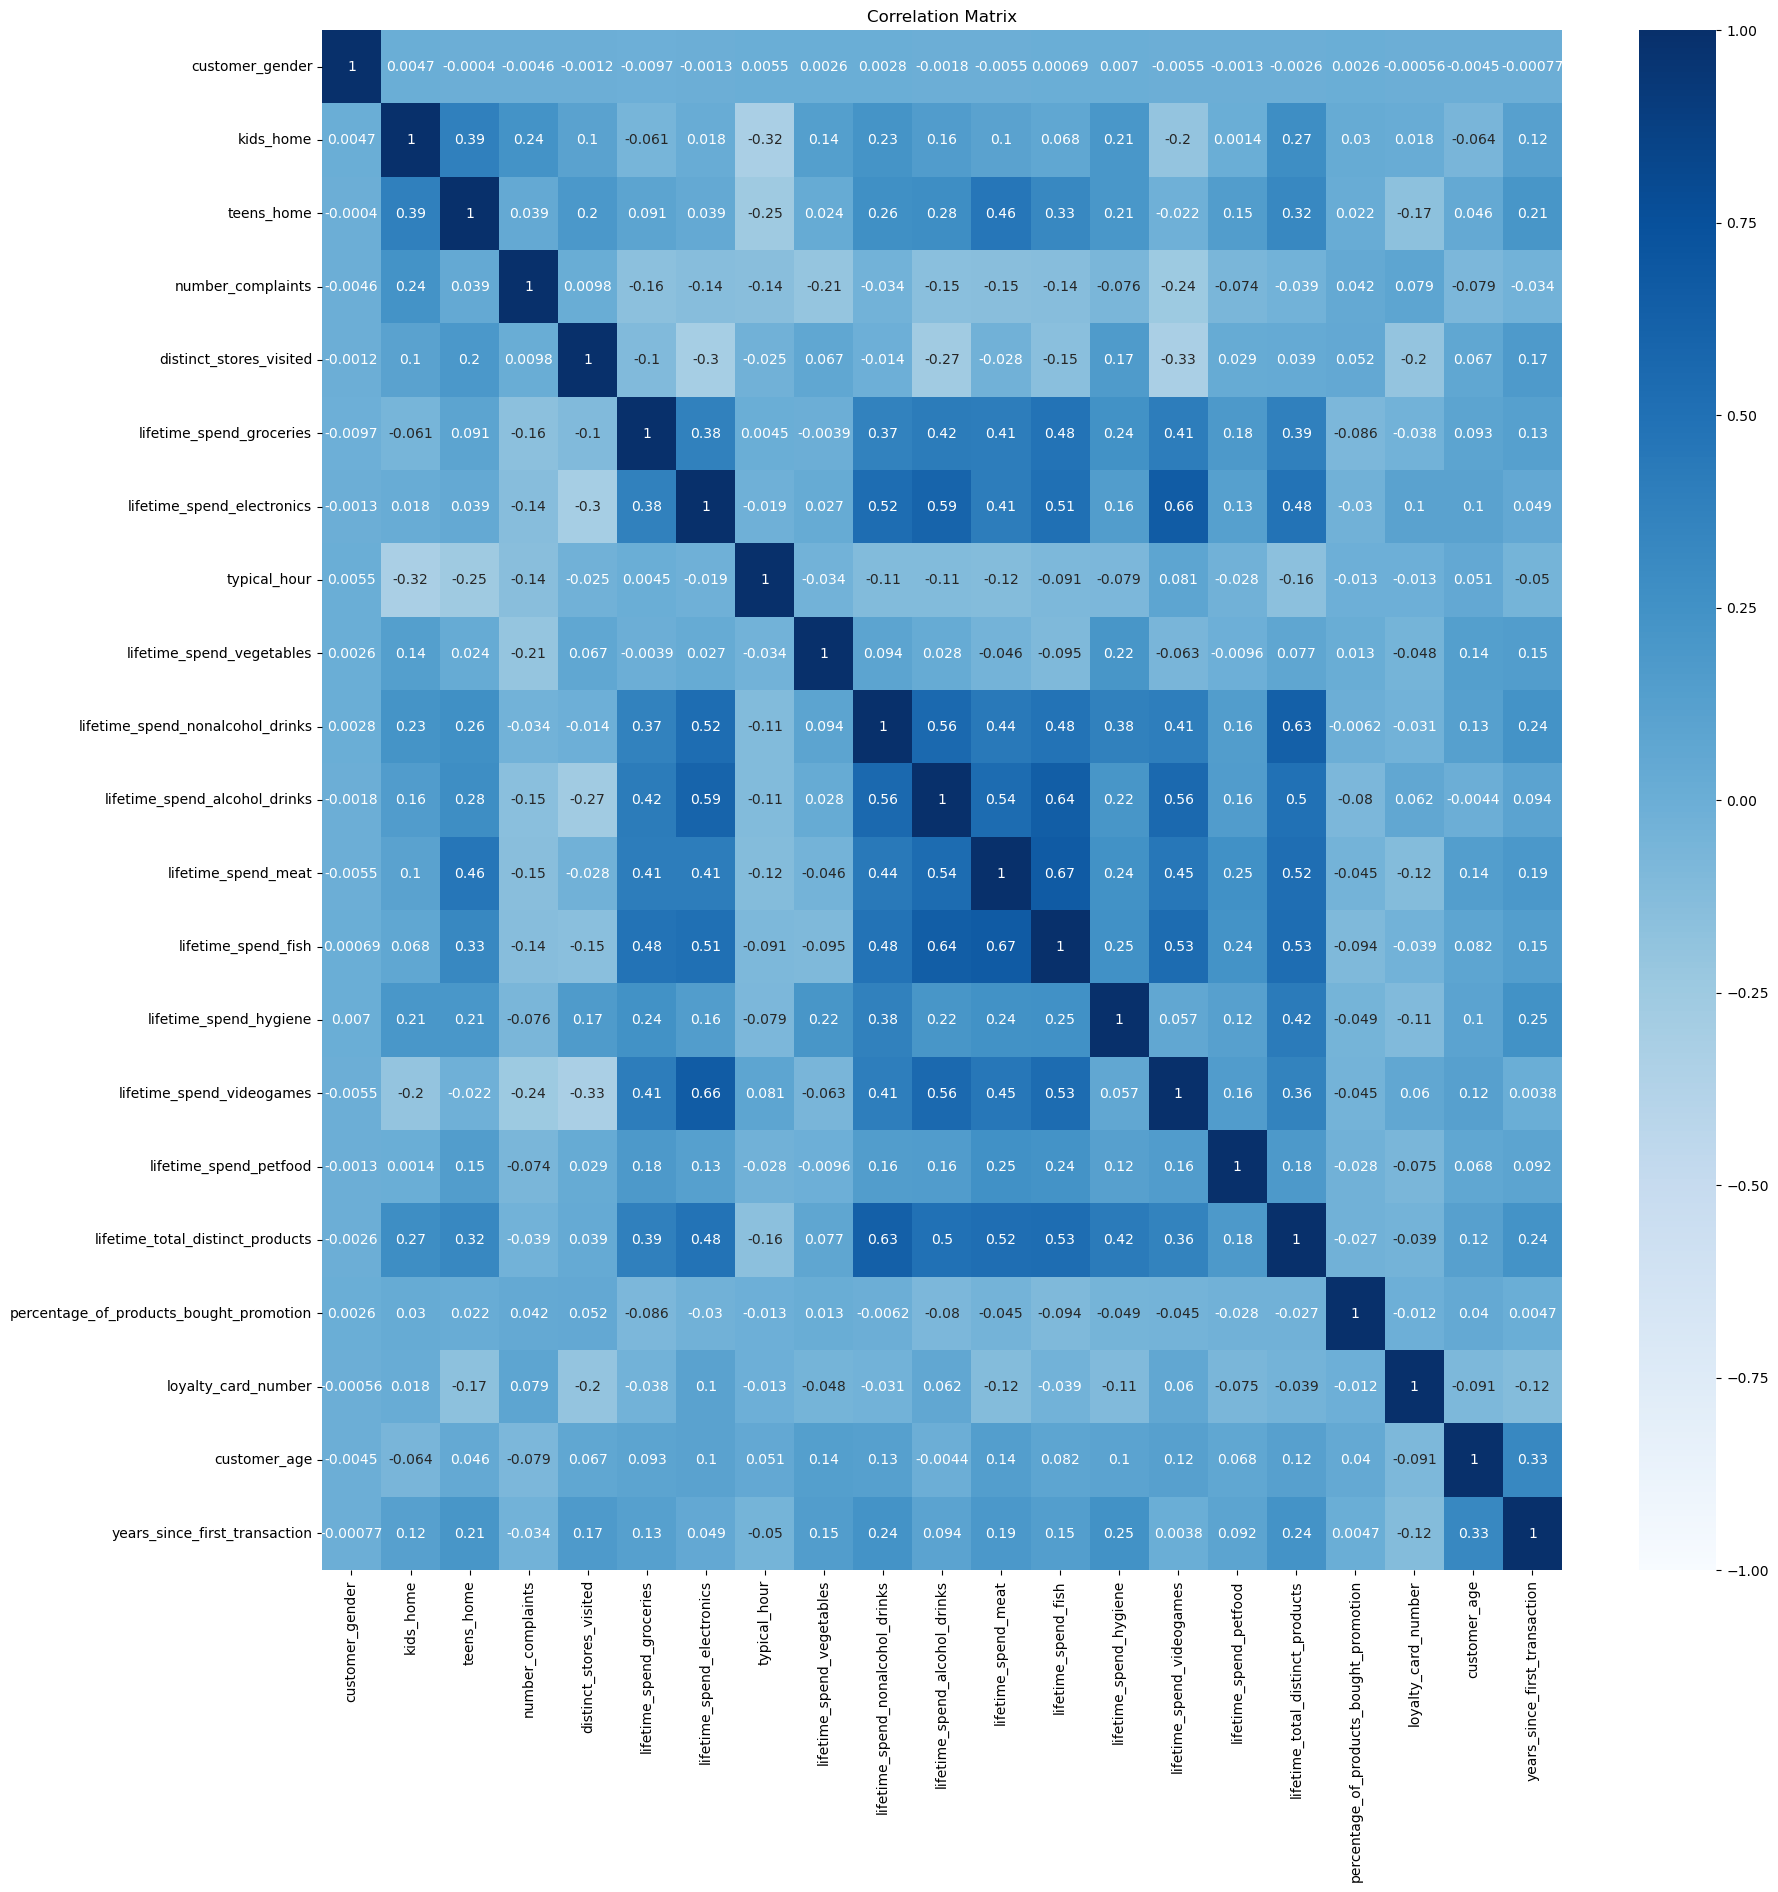

In [41]:
corr = dataset.corr(method='spearman')

plt.figure(figsize=(20, 20))
plt.title('Correlation Matrix')
sns.heatmap(corr, cmap='Blues', vmin=-1, vmax=1, annot=True)

In [ ]:
corr_unstacked = corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # remove self-correlations
top_corr = corr_unstacked.sort_values(ascending=False).drop_duplicates()

top_corr[top_corr > 0.60]

lifetime_spend_meat               lifetime_spend_fish                 0.669646
lifetime_spend_electronics        lifetime_spend_videogames           0.660468
lifetime_spend_fish               lifetime_spend_alcohol_drinks       0.641769
lifetime_spend_nonalcohol_drinks  lifetime_total_distinct_products    0.629941
dtype: float64

Here we will drop these two variables due to the very small variations on the profiles of the **clustering part of the project**.

We decided to include that on the pre-processing part, because when we scale and unscale with different number of features on the 'models' branch, we get an error because of the shape dimension.

In [43]:
dataset.drop(['customer_gender', 'percentage_of_products_bought_promotion'], axis=1, inplace=True)

In [44]:
dataset

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,loyalty_card_number,customer_age,years_since_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.383666,0.594200,0.000000,0.315483,1.183721,0.535375,1.004418,1.188259,-0.266968,0.289720,0.569307,1.526012,1.0,-0.032258,-0.428571
6813,-1.0,0.0,-1.0,0.5,-0.342666,-0.657149,0.142857,0.392317,-0.816279,-0.635692,-0.257732,-0.378543,-0.361991,-0.760125,-0.430693,-0.283237,0.0,0.838710,0.285714
39451,1.0,2.0,-1.0,2.0,-0.012765,0.296088,0.142857,1.315483,1.225581,1.231257,0.599411,1.266194,0.431373,0.049844,-0.599010,1.138728,1.0,-0.612903,0.571429
21557,-1.0,-1.0,0.0,-1.0,-0.115503,3.014388,0.142857,-0.497090,-0.427907,1.213305,0.033873,0.065789,-0.746606,1.121495,-0.212871,0.572254,1.0,-0.193548,0.857143
16415,0.0,0.0,0.0,1.0,1.583828,0.053732,0.142857,-0.229336,0.634884,-0.167899,0.098675,0.781377,0.621418,-0.644860,-0.836634,0.705202,0.0,0.129032,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.204100,0.515288,0.428571,0.416764,0.174419,0.863780,-0.337261,0.978745,0.624434,0.186916,-0.272277,0.236994,1.0,-0.903226,-0.428571
27422,0.0,0.0,-1.0,0.0,0.009965,0.188399,0.000000,0.054715,0.686047,-0.012672,0.418262,-0.153846,0.475113,-0.174455,0.029703,1.485549,0.0,-0.451613,-0.571429
39540,0.0,-1.0,0.0,-0.5,-0.058985,1.309802,0.571429,-0.061700,-0.444186,-0.234424,-0.599411,0.761134,-0.401207,1.510903,-1.004950,0.612717,1.0,-0.967742,-0.428571


---------------

## **MULTIDIMENSIONAL OUTLIERS**

### **DBSCAN**

Finding the best eps:

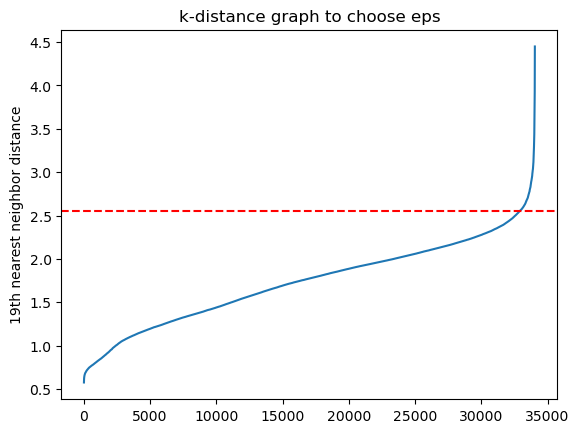

In [ ]:
nn = NearestNeighbors(n_neighbors=19)
n=nn.fit(dataset)
dist, i = nn.kneighbors(dataset)
dist = np.sort(dist[:, -1])
plt.plot(dist)
plt.ylabel("19th nearest neighbor distance")
plt.title("k-distance graph to choose eps")
plt.axhline(y=2.55, color='orange', linestyle='--')
plt.show()

The optimal eps is selected near the "elbow" or the point where the curve sharply increases

In [ ]:
dbscan = DBSCAN(eps=2.55, min_samples=20)
dbscan.fit(dataset)

DBSCAN(eps=2.55, min_samples=20)

In [49]:
labels = dbscan.labels_
outliers = dataset[labels == -1]
print(f"Number of Outliers: {len(outliers)}")

Number of Outliers: 179


In [50]:
dataset['cluster'] = labels

In [51]:
dataset = dataset[dataset['cluster'] != -1] # eliminating multidimensional outliers
dataset

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,loyalty_card_number,customer_age,years_since_first_transaction,cluster
customer_id,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.383666,0.594200,0.000000,0.315483,1.183721,0.535375,1.004418,1.188259,-0.266968,0.289720,0.569307,1.526012,1.0,-0.032258,-0.428571,0
6813,-1.0,0.0,-1.0,0.5,-0.342666,-0.657149,0.142857,0.392317,-0.816279,-0.635692,-0.257732,-0.378543,-0.361991,-0.760125,-0.430693,-0.283237,0.0,0.838710,0.285714,0
39451,1.0,2.0,-1.0,2.0,-0.012765,0.296088,0.142857,1.315483,1.225581,1.231257,0.599411,1.266194,0.431373,0.049844,-0.599010,1.138728,1.0,-0.612903,0.571429,0
21557,-1.0,-1.0,0.0,-1.0,-0.115503,3.014388,0.142857,-0.497090,-0.427907,1.213305,0.033873,0.065789,-0.746606,1.121495,-0.212871,0.572254,1.0,-0.193548,0.857143,0
16415,0.0,0.0,0.0,1.0,1.583828,0.053732,0.142857,-0.229336,0.634884,-0.167899,0.098675,0.781377,0.621418,-0.644860,-0.836634,0.705202,0.0,0.129032,0.428571,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37071,0.0,0.0,-1.0,-0.5,2.204100,0.515288,0.428571,0.416764,0.174419,0.863780,-0.337261,0.978745,0.624434,0.186916,-0.272277,0.236994,1.0,-0.903226,-0.428571,0
27422,0.0,0.0,-1.0,0.0,0.009965,0.188399,0.000000,0.054715,0.686047,-0.012672,0.418262,-0.153846,0.475113,-0.174455,0.029703,1.485549,0.0,-0.451613,-0.571429,0
39540,0.0,-1.0,0.0,-0.5,-0.058985,1.309802,0.571429,-0.061700,-0.444186,-0.234424,-0.599411,0.761134,-0.401207,1.510903,-1.004950,0.612717,1.0,-0.967742,-0.428571,0
